<a href="https://colab.research.google.com/github/JJJuniorDev/ML-colab/blob/main/CNN_computer_vision_basic_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import zipfile
# Download zip file of pizza_steak images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2026-02-25 22:24:14--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.253.134.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  18.7MB/s    in 6.9s    

2026-02-25 22:24:22 (15.2 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [3]:
import os
#unzip
zip_ref=zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

In [4]:
num_steak_images_train=len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [5]:
import pathlib
import numpy as np
data_dir=pathlib.Path("pizza_steak/train")
class_names=np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [6]:
import matplotlib.image as mpimg
import random
def view_random_image(target_dir, target_class):
  #target directory
  target_folder=target_dir+target_class
  #get a random image path
  random_image=random.sample(os.listdir(target_folder), 1)
  img=mpimg.imread(target_folder+"/"+random_image[0])
  plt.imshow(img) #mostra immagine
  plt.title(target_class) #pizza or steak
  plt.axis("off")
  print(f"Image shape: {img.shape}")
  return img

Image shape: (512, 512, 3)


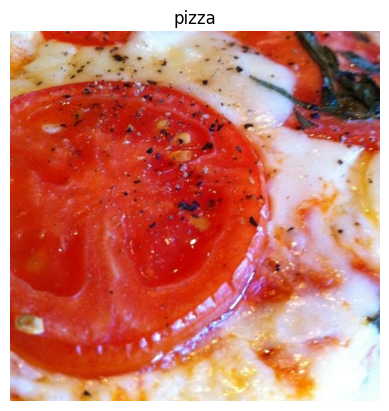

In [7]:
img= view_random_image(target_dir="pizza_steak/train/",
                       target_class="pizza")

In [8]:
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[214, 227, 233],
        [217, 232, 239],
        [217, 233, 246],
        ...,
        [185, 152, 135],
        [192, 157, 137],
        [196, 161, 139]],

       [[213, 222, 229],
        [219, 229, 238],
        [221, 235, 246],
        ...,
        [187, 155, 144],
        [189, 156, 141],
        [189, 156, 139]],

       [[208, 211, 220],
        [217, 221, 232],
        [224, 232, 245],
        ...,
        [192, 164, 161],
        [190, 161, 157],
        [187, 158, 152]],

       ...,

       [[212, 119,  50],
        [208, 115,  46],
        [205, 108,  39],
        ...,
        [245, 254, 253],
        [245, 254, 253],
        [245, 254, 253]],

       [[223, 133,  57],
        [215, 123,  46],
        [208, 112,  35],
        ...,
        [245, 254, 253],
        [246, 255, 254],
        [246, 255, 254]],

       [[238, 149,  69],
        [225, 134,  53],
        [210, 117,  37],
        ...,
        [245, 254, 25

In [9]:
img.shape #width, height, colour channels

(512, 512, 3)

creiamo una CNN per trovare patterns nelle immagini, dobbiamo:


*   Caricare le immagini
*   Pre processarle
*   Costruire la CNN
*   Compilare la CNN
*   Fittare la CNN



In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

#preprocessing (rendiamo i pixel tra 0 e 1 [scaling/normalizing])
train_datagen=ImageDataGenerator(rescale=1./255)
valid_datagen=ImageDataGenerator(rescale=1./255)

#set up paths per le directories
train_dir="/content/pizza_steak/train"
test_dir="pizza_steak/test"
#import dalle directories e trasformiamo in batches
train_data=train_datagen.flow_from_directory(directory=train_dir,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             seed=42)
valid_data= valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                              seed=42)

#Costruzione CNN
model_CNN=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

#Compiliamo la CNN
model_CNN.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(),
                   metrics=["accuracy"])
#flow_from_directory sopra crea dati e labels insieme in train_data
history_CNN=model_CNN.fit(train_data, epochs=5, steps_per_epoch=len(train_data),
                          validation_data=valid_data, validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.5645 - loss: 0.6983 - val_accuracy: 0.7840 - val_loss: 0.4506
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.7871 - loss: 0.4798 - val_accuracy: 0.8300 - val_loss: 0.4028
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8061 - loss: 0.4323 - val_accuracy: 0.8500 - val_loss: 0.3876
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.8056 - loss: 0.4460 - val_accuracy: 0.8560 - val_loss: 0.3665
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8240 - loss: 0.3973 - val_accuracy: 0.8100 - val_loss: 0.4140


In [11]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)